LOADING IRIS DATASET

Dataset Shape:
(150, 5)

Dataset Columns:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First Five Records:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Checking Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Dataset Shape After Cleaning:
(150, 5)

Duplicate Records: 1


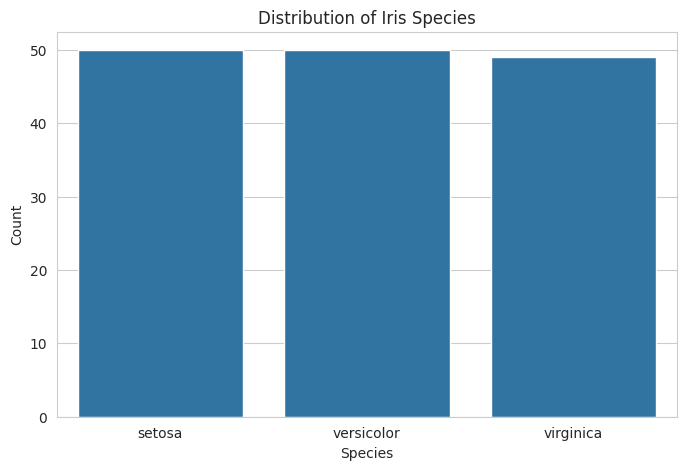

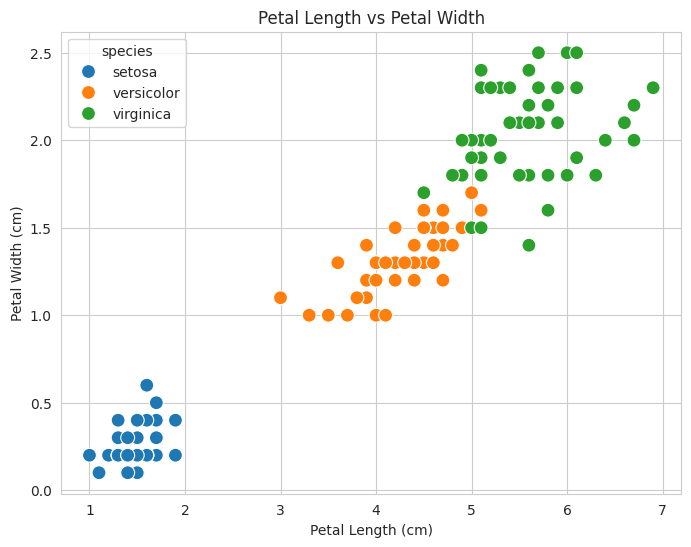

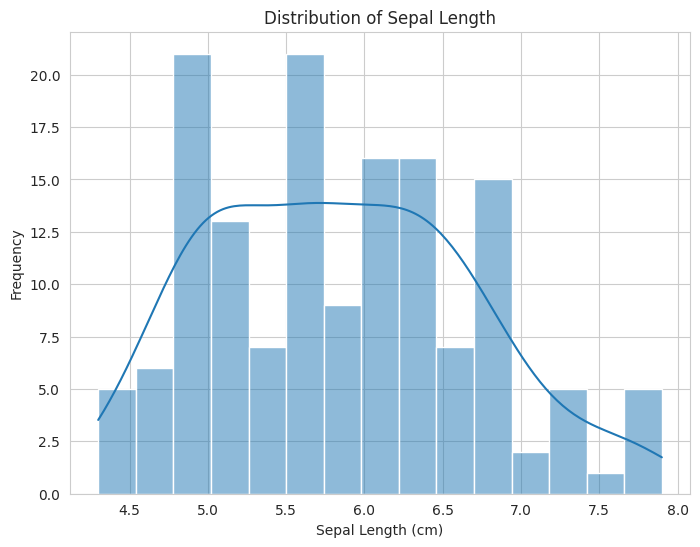

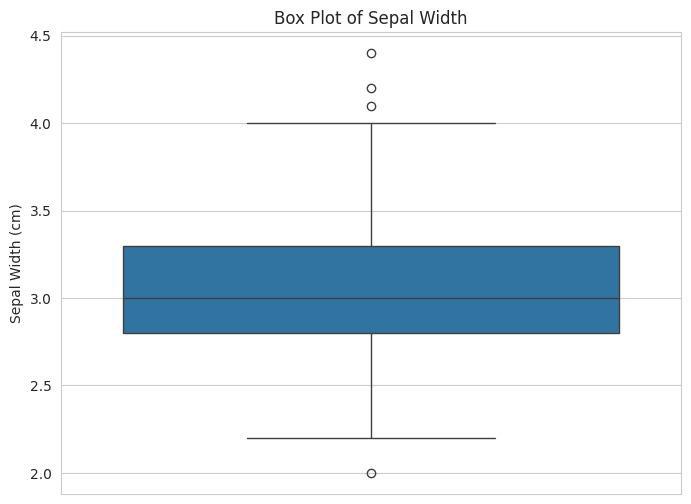

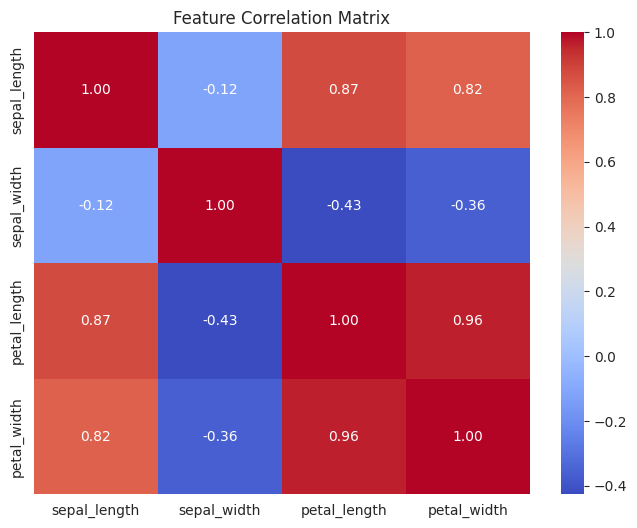

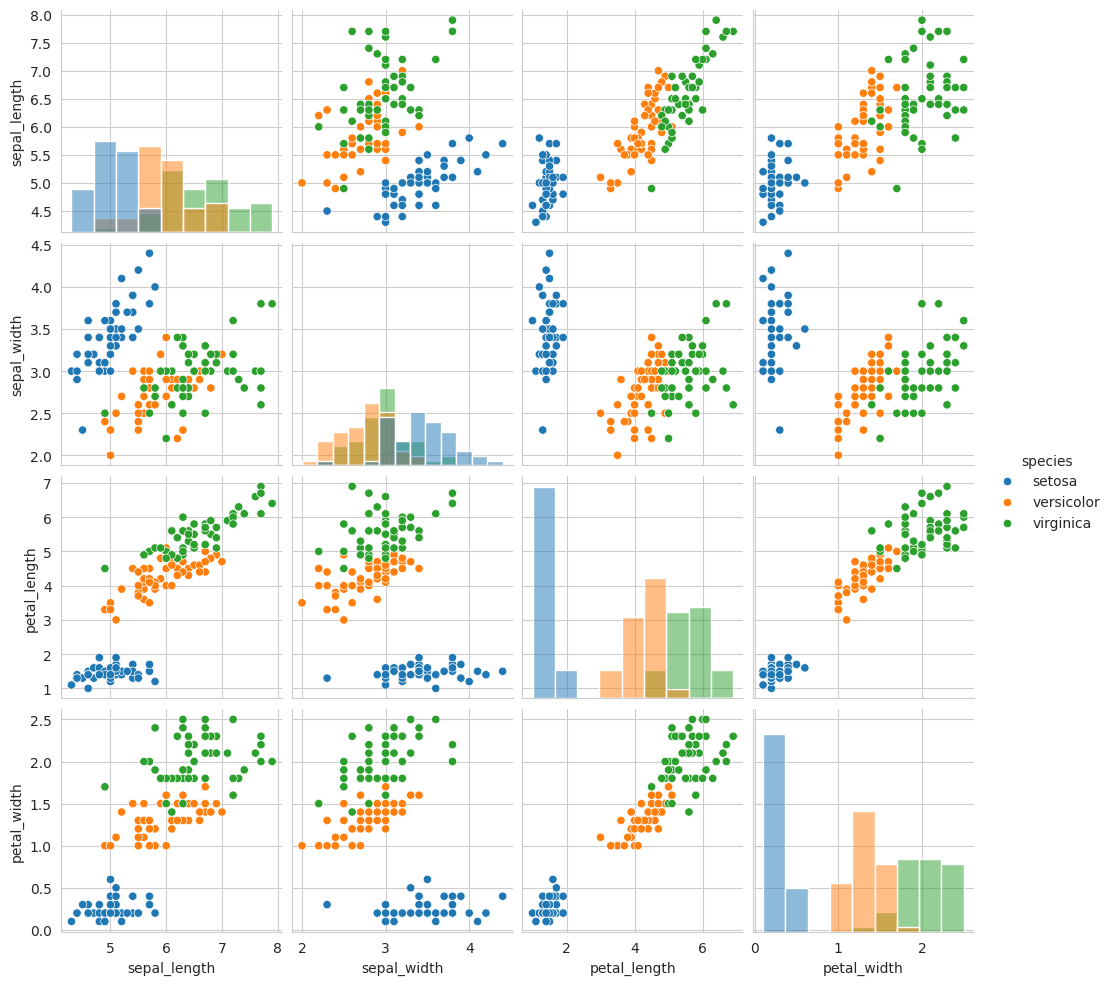


Training Samples : 119
Testing Samples  : 30

MODEL EVALUATION
Accuracy Score: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



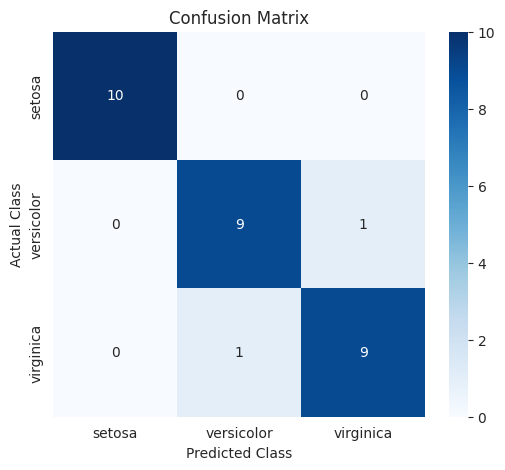

In [6]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set visualization style
sns.set_style("whitegrid")

# -------------------------
# 2. Load Dataset
# -------------------------
print("=" * 60)
print("LOADING IRIS DATASET")
print("=" * 60)

iris_df = sns.load_dataset("iris")

# -------------------------
# 3. Dataset Understanding
# -------------------------
print("\nDataset Shape:")
print(iris_df.shape)

print("\nDataset Columns:")
print(iris_df.columns.tolist())

print("\nFirst Five Records:")
display(iris_df.head())

print("\nDataset Information:")
iris_df.info()

print("\nStatistical Summary:")
display(iris_df.describe())

# -------------------------
# 4. Data Cleaning
# -------------------------
print("\nChecking Missing Values:")
print(iris_df.isnull().sum())

# Remove missing values if any exist
iris_df.dropna(inplace=True)

print("\nDataset Shape After Cleaning:")
print(iris_df.shape)

# Check duplicate records
duplicates = iris_df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

# Remove duplicates if present
iris_df.drop_duplicates(inplace=True)

# -------------------------
# 5. Exploratory Data Analysis
# -------------------------

# Species Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=iris_df, x="species")
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# -------------------------
# Scatter Plot
# -------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris_df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

# -------------------------
# Histogram
# -------------------------
plt.figure(figsize=(8, 6))
sns.histplot(
    data=iris_df,
    x="sepal_length",
    bins=15,
    kde=True
)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# Box Plot
# -------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=iris_df,
    y="sepal_width"
)

plt.title("Box Plot of Sepal Width")
plt.ylabel("Sepal Width (cm)")
plt.show()

# -------------------------
# Correlation Heatmap
# -------------------------
plt.figure(figsize=(8, 6))

numeric_data = iris_df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

# -------------------------
# Pair Plot
# -------------------------
sns.pairplot(
    iris_df,
    hue="species",
    diag_kind="hist"
)

plt.show()

# -------------------------
# 6. Model Training
# -------------------------

# Feature Matrix
X = iris_df.drop("species", axis=1)

# Target Variable
y = iris_df["species"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# -------------------------
# Train Decision Tree Model
# -------------------------
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------
# 7. Model Testing
# -------------------------
y_pred = model.predict(X_test)

# -------------------------
# 8. Evaluation Metrics
# -------------------------

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy Score: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

